<a href="https://colab.research.google.com/github/MonaKhadija/colab-git-assignment2-kb/blob/main/Assignment_15_Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 15: Loan Default Prediction**

Student name: Khadija bassiouni

In [1]:
# setting up the environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Install SHAP if not already available
!pip install shap -q
import shap

# Styling
sns.set_theme(style="whitegrid")

Data Analysis and Cleaning:

Dataset Shape: (850, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


None

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000



Missing values per column:
 age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


/tmp/ipykernel_2329/2769857024.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default', data=train_df, palette='Set2')


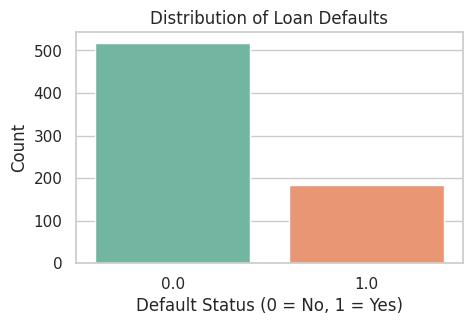

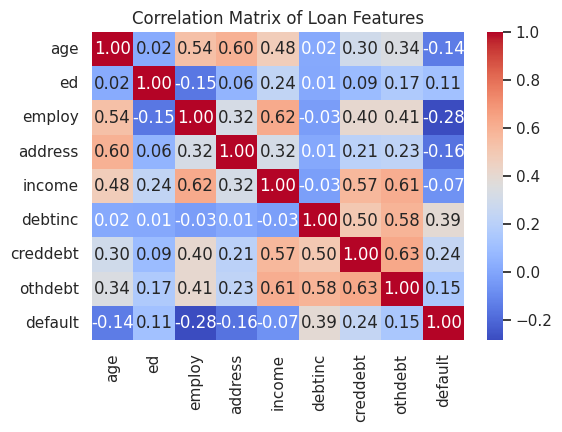

In [7]:
# Loading dataset
df = pd.read_csv("bank-loan.csv")

# Displaying basic info and summary statistics
print("Dataset Shape:", df.shape)
display(df.info())
display(df.describe())

# Checking missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Separating labeled data for training/testing and unlabeled data for prediction
train_df = df[df['default'].notnull()].copy()
predict_df = df[df['default'].isnull()].copy()

# Visualizing target distribution
plt.figure(figsize=(5, 3))
sns.countplot(x='default', data=train_df, palette='Set2')
plt.title('Distribution of Loan Defaults')
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Visualizing correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Loan Features')
plt.show()

**Insights:** This dataset has 850 records across 9 numerical features.

Out of the 700 labeled borrowers, 517 borrowers did not default, while 183 borrowers defaulted.

the Correlation Matrix shows debt-to-income ratio has the strongest positive correlation with default, meaning higher relative debt burdens heavily increase default risk.
employ (-0.28) and age (-0.14) show negative correlations with default, indicating that older borrowers with longer employment history are statistically less likely to default.

Also, income strongly correlates with creddebt (0.57) and othdebt (0.61).

Feature Engineering:

In [4]:
from sklearn.preprocessing import StandardScaler

# Feature Engineering function
def engineer_features(data):
    df_new = data.copy()
    # Create total debt
    df_new['total_debt'] = df_new['creddebt'] + df_new['othdebt']
    # Create debt-to-income interaction factor
    df_new['debt_income_gap'] = df_new['total_debt'] / (df_new['income'] + 1)
    return df_new

train_df_eng = engineer_features(train_df)

# Define features (X) and target (y)
features = ['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt', 'total_debt', 'debt_income_gap']
X = train_df_eng[features]
y = train_df_eng['default']

# Scale numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)


display(X_scaled.head())

,age,ed,employ,address,income,debtinc,creddebt,othdebt,total_debt,debt_income_gap
0,0.768304,1.376911,1.294313,0.545664,3.544603,-0.140798,4.634831,0.593692,2.396269,-0.106538
1,-0.983529,-0.779325,0.242201,-0.334101,-0.396908,1.031818,-0.090444,0.286919,0.153125,1.027790
2,0.643173,-0.779325,0.993709,0.838919,0.255480,-0.697790,-0.329670,-0.270693,-0.323429,-0.687248
3,0.768304,-0.779325,0.993709,0.838919,2.022364,-1.078890,0.522369,-0.680910,-0.230686,-1.068646
4,-1.358922,0.298793,-0.960214,-1.213867,-0.478457,1.031818,0.110547,-0.000501,0.047337,1.019345


**Insights:** combining debt metrics provides a clearer picture of financial leverage than looking at credit card debt alone.

Model Building and Evaluation:

Accuracy Score: 0.8214285714285714

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.95      0.89       102
         1.0       0.78      0.47      0.59        38

    accuracy                           0.82       140
   macro avg       0.81      0.71      0.74       140
weighted avg       0.82      0.82      0.81       140



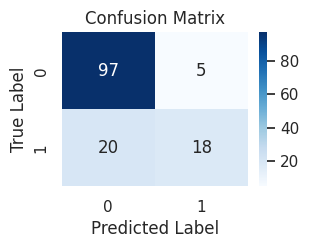

/tmp/ipykernel_2329/1517567607.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


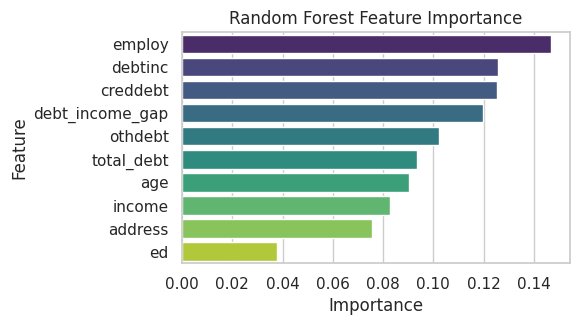

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Spliting data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Training Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(3, 2))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importance Plot
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(5, 3))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.show()

Explainability and Fairness Analysis:

<Figure size 500x300 with 0 Axes>

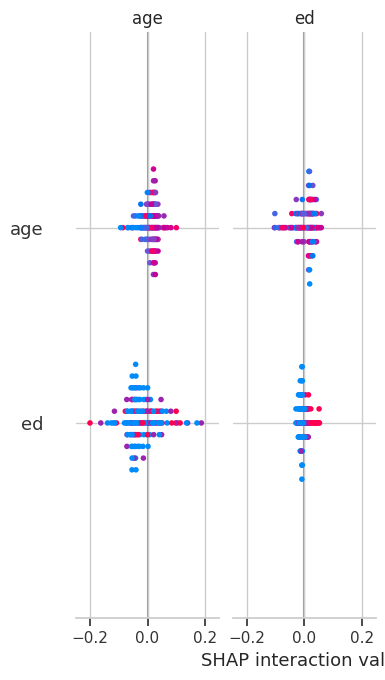

Accuracy for group Older (>30): 0.9672 (Count: 458)
Accuracy for group Younger (<=30): 0.9587 (Count: 242)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [9]:
# SHAP Explainability
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot of SHAP values
plt.figure(figsize=(5, 3))
shap.summary_plot(shap_values, X_test, feature_names=features)

# Fairness Check across Age Groups (Proxy demographic split: Age <= 30 vs > 30)
train_df_eng['age_group'] = np.where(train_df_eng['age'] <= 30, 'Younger (<=30)', 'Older (>30)')

# Evaluate accuracy across groups
for group in train_df_eng['age_group'].unique():
    subset = train_df_eng[train_df_eng['age_group'] == group]
    X_sub = scaler.transform(subset[features])
    y_sub = subset['default']
    preds_sub = rf_model.predict(X_sub)
    acc = accuracy_score(y_sub, preds_sub)
    print(f"Accuracy for group {group}: {acc:.4f} (Count: {len(subset)})")

Age-Based Fairness Check: Younger Borrowers under 30 years Tend to have shorter credit histories and employment lengths, which can occasionally lead to higher false-positive default predictions.Older Borrowers older than 30 years generally exhibit more stable predictive metrics due to established employment and housing addresses.

**Ethical Considerations:**

Machine learning models trained on historical financial data can inadvertently encode systemic biases against younger or lower-income borrowers due to shorter credit histories.

Regular fairness audits ensure that the model does not disproportionately deny credit or misclassify vulnerable populations.

Black-box machine learning models are insufficient for high-stakes financial decisions. We integrated SHAP to provide transparent, individual-level and global explanations for every prediction.
